# Nobel Prize Analysis Notebook
#### Description: Analyzing Nobel Prize winner data to identify patterns in gender, birth country, and decades.
Author: Abdenacer Kerrouche

## 1. Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 2. Load Data

In [ ]:
df = pd.read_csv("../data/nobel.csv")
df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


## 3. Most Common Gender and Birth Country

In [7]:
top_gender = df['sex'].mode().iloc[0]
top_country = df['birth_country'].mode().iloc[0]

print('Most common gender:', top_gender)
print('Most common birth country:', top_country)

Most common gender: Male
Most common birth country: United States of America


## 4. US-born Ratio by Decade

Decade with highest US-born ratio: 2000


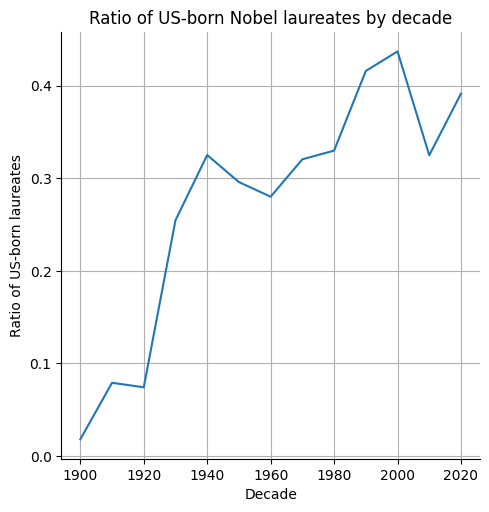

In [13]:
df['US_born'] = (df['birth_country'] == 'United States of America')
df['born'] = df['birth_country'].notnull()
df['decade'] = df['year'].apply(lambda x: (x // 10) * 10 if pd.notnull(x) else None)

decade = df.groupby('decade').sum()
decade['Ratio'] = decade['US_born'] / decade['born']
max_decade_usa = decade['Ratio'].idxmax()

print('Decade with highest US-born ratio:', max_decade_usa)

sns.relplot(x='decade', y='Ratio', data=decade, kind='line')
plt.title('Ratio of US-born Nobel laureates by decade')
plt.xlabel('Decade')
plt.ylabel('Ratio of US-born laureates')
plt.grid()
plt.show()

## 5. Female Ratio by Decade and Category

Decade and category with highest female ratio: {np.int64(2020): 'Literature'}


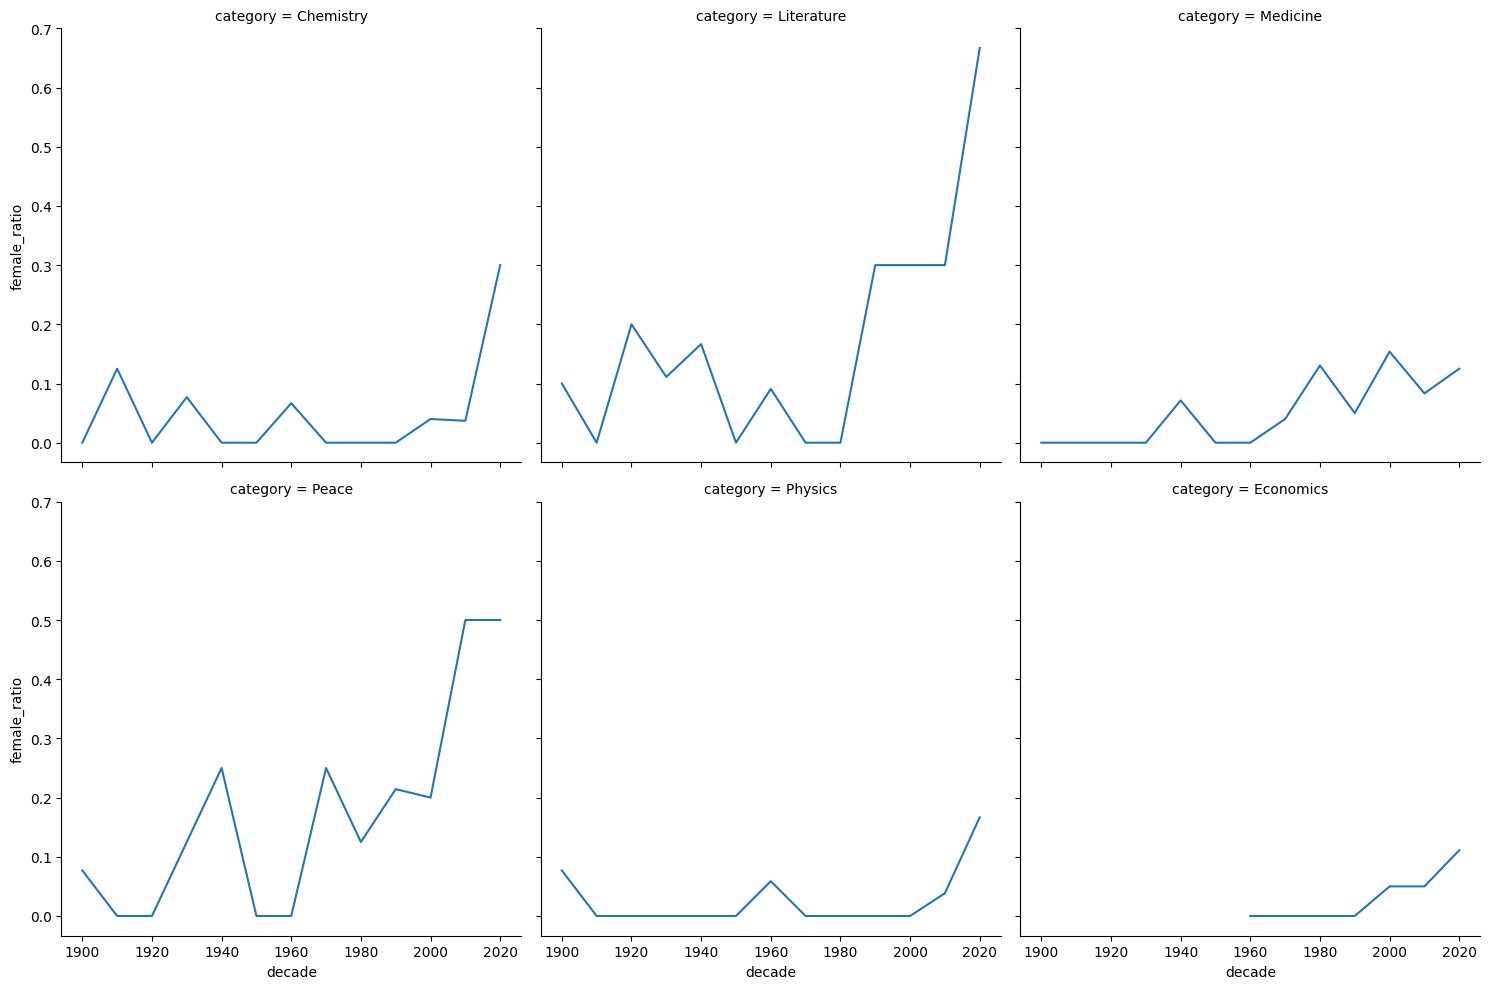

In [9]:
df['female'] = (df['sex'] == 'Female')
combo = df.groupby(['decade', 'category']).sum()
combo['female_ratio'] = combo['female'] / combo['born']
max_female_tuple = combo['female_ratio'].idxmax()
max_female_dict = {max_female_tuple[0]: max_female_tuple[1]}

print('Decade and category with highest female ratio:', max_female_dict)

sns.relplot(x='decade', y='female_ratio', data=combo, kind='line', col='category', col_wrap=3)

## 6. First Female Nobel Winner

In [10]:
female = df[df['sex'] == 'Female'].sort_values('year')
first_woman_name = str(list(female.iloc[0][['full_name']])[0])
first_woman_category = str(list(female.iloc[0][['category']])[0])

print('First female Nobel winner:', first_woman_name)
print('Category:', first_woman_category)

First female Nobel winner: Marie Curie, née Sklodowska
Category: Physics


## 7. Individuals with Multiple Awards

In [11]:
ind_counts = df['full_name'].value_counts()
ind_multiple = ind_counts[ind_counts > 1].index
repeat_list = list(ind_multiple)

print('Individuals with multiple Nobel Prizes:', repeat_list)

Individuals with multiple Nobel Prizes: ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Frederick Sanger', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)', 'John Bardeen', 'Linus Carl Pauling']
